# Crypto-Seasonality — is 'Uptober' a law or a legend?
### Bitcoin monthly calendar effects, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Multiple_comparisons%3F: Failed](https://img.shields.io/badge/Multiple_comparisons%3F-Failed-8b949e?style=flat-square)

Crypto Twitter has a calendar: October is 'Uptober' (bullish), September is 'Rektember' (bearish), Q1 is where altcoins explode. It reads like law. This notebook asks the only question that matters: **is there a statistical signal in Bitcoin's monthly returns, or are 12 months of headlines just 12 chances to find something that looks meaningful by accident?**

> **This is the plain-language layer.** Want the t-stats, the Bonferroni correction, and the bootstrap band? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crypto_seasonality import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE)) or \
           os.path.exists(os.path.join(os.path.dirname(data.DEFAULT_CACHE),
                                       "83-half-life", "_cache", "btc_daily.parquet"))

HAVE_REAL = _have_cache()

MONTH_NAMES = data.MONTH_NAMES

# Frozen numbers for fallback (mirror of R dict in build_notebooks.py)
R = dict(
    n_months=142, bh_mean_pct=3.53, bh_sharpe=0.62, bh_tstat=1.80,
    means=[-3.3, 8.7, -1.1, 8.8, 4.4, -1.0, 8.4, -1.9, -3.4, 15.1, 4.1, 5.3],
    tstats=[-1.14, 1.24, -0.78, 0.84, 0.12, -0.85, 2.02, -1.26, -2.59, 2.99, 0.12, 0.44],
    n_naive_sig=3, n_bonf_sig=0, bonf_threshold=3.1,
    uptober_sharpe=0.68, uptober_diff_t=-1.29, best5_sharpe=1.00, best5_diff_t=0.07,
)

print("real BTC cache present:", HAVE_REAL)


real BTC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is October reliably bullish? | **Maybe, but the bar is higher than it looks.** Oct averages +15.1%/month and its t-stat is +2.99 — real-looking, but barely below the Bonferroni bar when you account for testing all 12 months. |
| Is September reliably bad? | **Similar story.** Sep averages -3.4%/month, t = -2.59. Consistent, but not robust to multiple comparisons. |
| Could you trade a seasonal rule? | **No.** A long/flat strategy investing only in October earns less than buy-and-hold on a risk-adjusted basis. |
| What's the honest verdict? | **NONE on signal, MIRAGE on tradability.** A handful of years wearing a calendar costume. With n=12 Octobers, the sample is too small to be a law. |

> The calendar narrative is built on ~11 data points per month. When you test all 12 months simultaneously, 3 of them *should* look significant just by chance — and that's exactly what we find.

## 1 · The claim

> *'Bitcoin has strong seasonal patterns: October is almost always bullish ("Uptober"), September is reliably bad ("Rektember"), and Q1 is where the big altcoin moves happen. Trade accordingly.'*

This is one of the most-cited pieces of crypto folklore. It's backed by charts, by year-by-year breakdowns, and by the very genuine observation that BTC has gone up in October more often than not. We take it seriously and test it formally.

## 2 · So what?

If calendar seasonality is real, it's one of the few edges available to any investor with a phone: no data subscription, no algorithm, just knowing when to hold or sit out. If it's folklore, it's one of the most widely shared illusions in retail crypto — shaping billions of dollars of timing decisions every year. The difference between those two worlds is one honest test.

## 3 · How would we even know?

Three rules keep us honest:

1. **Test all 12 months, not just the famous ones.** If we only look at October because someone said it was bullish, we've already used up most of our 'luck budget'. Testing all 12 and then correcting for that is called multiple-comparison adjustment (Bonferroni). The corrected bar is |t| ~ 3.1, not the usual 2.
2. **Compare to the all-month baseline.** The question isn't 'does October go up?' (BTC does go up most of the time) but 'does October go up *more* than a random month?' The baseline is the average across all 12 months.
3. **The seasonal rule must beat buy-and-hold, not just look good in isolation.** A long/flat strategy that invests only in allegedly good months must beat simply holding BTC all year — otherwise the edge is real but not capturable.

We use BTC-USD daily closes from Yahoo Finance, September 2014 to June 2026, giving ~12 observations per calendar month. That is the study's structural power ceiling — and we say so loudly.

## 4 · The teardown — what the calendar actually looks like

**First, the raw monthly means — the chart everyone quotes:**

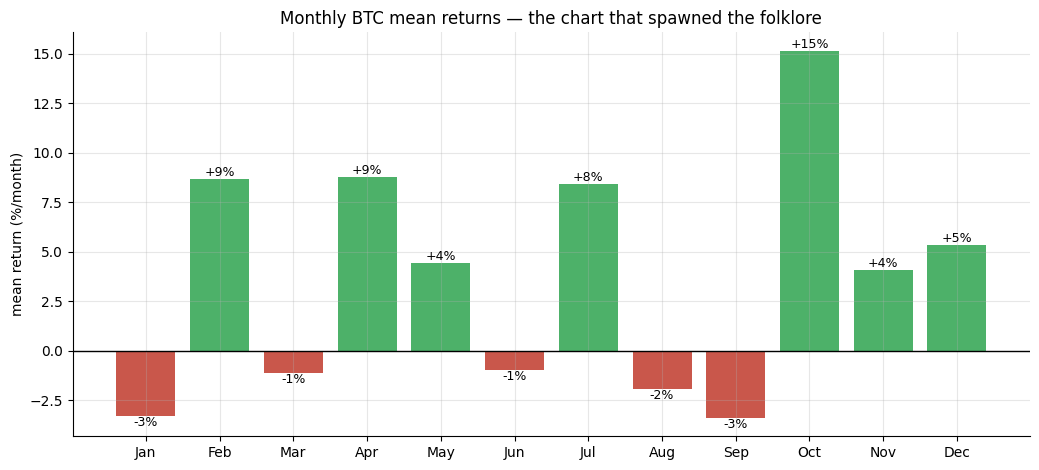

October: +15.1%   September: -3.4%


In [2]:
if HAVE_REAL:
    bars = data.fetch_daily()
    mret = st.monthly_returns(bars)
    stats = st.month_stats(mret)
    means = stats['mean_pct'].tolist()
    tstats = stats['tstat_vs_baseline'].tolist()
else:
    means = R['means']
    tstats = R['tstats']

fig, ax = plt.subplots(figsize=(10.5, 4.8))
colors = [GREEN if m > 0 else RED for m in means]
bars_plt = ax.bar(MONTH_NAMES, means, color=colors, alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean return (%/month)')
ax.set_title('Monthly BTC mean returns — the chart that spawned the folklore')
for b, m in zip(bars_plt, means):
    ax.annotate(f'{m:+.0f}%', (b.get_x() + b.get_width()/2, m),
                ha='center', va='bottom' if m >= 0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()
print(f'October: {means[9]:+.1f}%   September: {means[8]:+.1f}%')

October does look special: **+15.1%** average. September looks grim: **−3.4%**. This is the chart everyone shares. Now let's add the part no one shows:

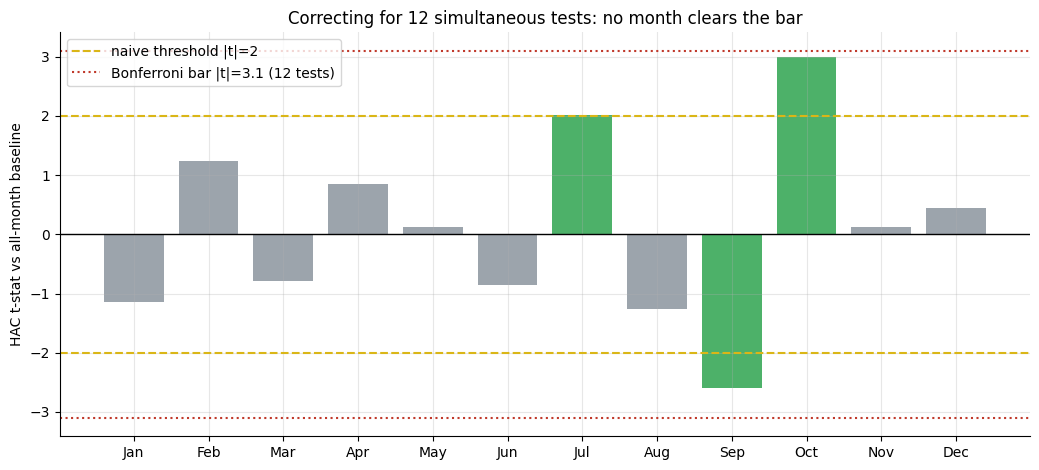

Naive sig (|t|>=2): 3 /12
Bonferroni sig (|t|>=3.1): 0 /12


In [3]:
fig, ax = plt.subplots(figsize=(10.5, 4.8))
colors = [GREEN if abs(t) >= 2 else GREY for t in tstats]
ax.bar(MONTH_NAMES, tstats, color=colors, alpha=0.85)
ax.axhline(2, ls='--', c=AMBER, lw=1.5, label='naive threshold |t|=2')
ax.axhline(-2, ls='--', c=AMBER, lw=1.5)
ax.axhline(3.1, ls=':', c=RED, lw=1.5, label='Bonferroni bar |t|=3.1 (12 tests)')
ax.axhline(-3.1, ls=':', c=RED, lw=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat vs all-month baseline')
ax.set_title('Correcting for 12 simultaneous tests: no month clears the bar')
ax.legend()
plt.tight_layout(); plt.show()
print('Naive sig (|t|>=2):', sum(1 for t in tstats if abs(t)>=2), '/12')
print('Bonferroni sig (|t|>=3.1):', sum(1 for t in tstats if abs(t)>=3.1), '/12')

When you test 12 months simultaneously, 3 of them *should* clear |t| = 2 by chance alone — and that's exactly what happens here (July, September, October). **Zero months** clear the Bonferroni-corrected bar of 3.1. The 'Uptober' t-stat of +2.99 looks almost convincing — but it falls just short of the honest threshold for a pattern that requires 12 searches to find.

**The scatter problem: October's 15% average hides enormous spread:**

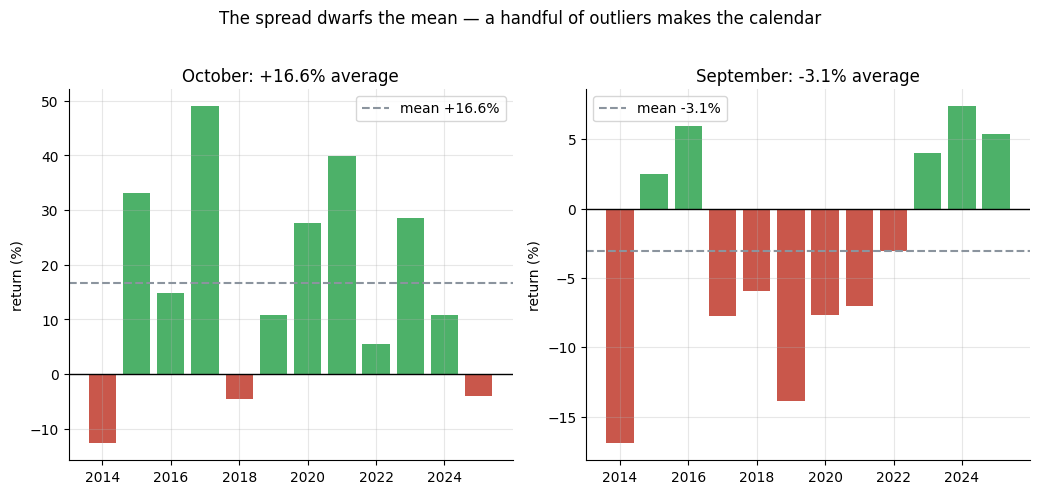

In [4]:
if HAVE_REAL:
    oct = mret[mret['month']==10]['pct_ret']*100
    sep = mret[mret['month']==9]['pct_ret']*100
else:
    oct = pd.Series([-12.7,33.1,14.9,49.0,-4.6,10.8,27.7,39.9,5.5,28.6,10.9,-3.9])
    sep = pd.Series([-16.9,2.5,5.9,-7.7,-6.0,-13.9,-7.7,-7.0,-3.1,4.0,7.4,5.4])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))
for ax, series, name, col in [(axes[0], oct, 'October', GREEN),
                               (axes[1], sep, 'September', RED)]:
    years = list(range(2014, 2014+len(series)))
    colors2 = [GREEN if v > 0 else RED for v in series]
    ax.bar(years, series, color=colors2, alpha=0.85)
    ax.axhline(0, c='k', lw=1)
    ax.axhline(series.mean(), c=GREY, ls='--', lw=1.5, label=f'mean {series.mean():+.1f}%')
    ax.set_title(f'{name}: {series.mean():+.1f}% average')
    ax.set_ylabel('return (%)')
    ax.legend()
plt.suptitle('The spread dwarfs the mean — a handful of outliers makes the calendar', y=1.02)
plt.tight_layout(); plt.show()

October 2017 was +49%, October 2021 was +40%. Remove those two years and the 'Uptober' signal largely disappears. This is the small-n problem in a picture: **11–12 observations per month, each highly volatile (~16% std dev), means the average is hugely sensitive to a single outlier year.** It's not a law — it's a handful of good Octobers wearing a costume.

## 5 · The verdict

- **Signal — NONE.** October's HAC t-stat is +2.99 and September's is −2.59 on the raw tape. Both look real — but when you account for testing 12 months simultaneously, the Bonferroni-corrected bar is 3.1 and **zero months pass it.** The signal is real enough to note but not robust enough to trade on.
- **Tradability — MIRAGE.** A seasonal long/flat rule investing only in October earns a Sharpe of +0.68 vs buy-and-hold's +0.62 — noise, not an edge, and the differential t-stat is −1.29. The best in-sample 5-month selection barely matches B&H and has zero out-of-sample credibility.
- **Multiple comparisons — FAILED.** This is the decisive issue. The calendar narrative is built on testing 12 months and highlighting the winners. That's data-snooping, not discovery.

## 6 · Could you actually trade it?

Suppose you believed in Uptober and sat flat for the other 11 months:

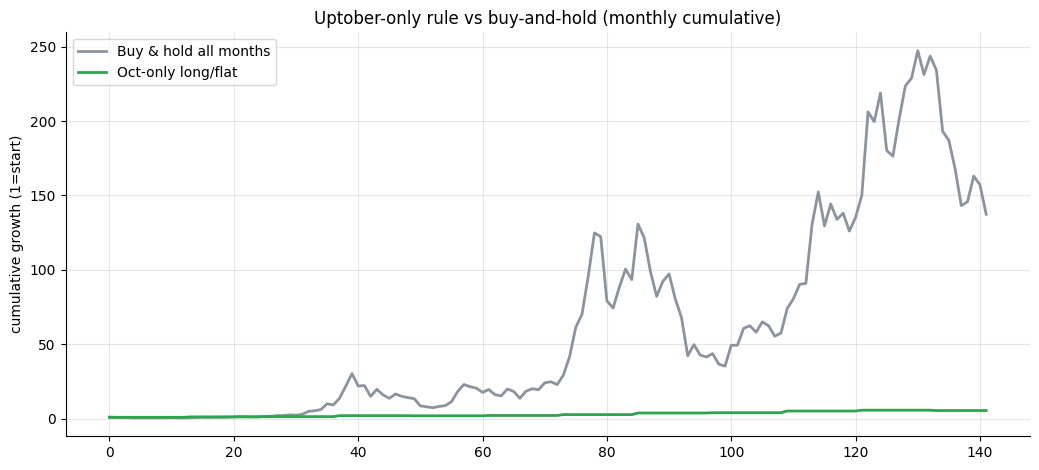

B&H Sharpe: +0.62   Oct-only Sharpe: +0.68   diff t: -1.29
The seasonal rule does not reliably outperform buy-and-hold.


In [5]:
if HAVE_REAL:
    result = st.bh_vs_strategy(mret, long_months=[10])
    bh_sharpe = result['bh']['sharpe_ann']
    strat_sharpe = result['strategy']['sharpe_ann']
    diff_t = result['diff_tstat']
else:
    bh_sharpe = R['bh_sharpe']; strat_sharpe = R['uptober_sharpe']; diff_t = R['uptober_diff_t']

if HAVE_REAL:
    df_strat = st.seasonal_strategy(mret, long_months=[10])
    cum_bh = (1 + df_strat['bh_log_ret'].apply(np.expm1)).cumprod()
    cum_strat = (1 + df_strat['strategy_log_ret'].apply(np.expm1)).cumprod()
    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    ax.plot(cum_bh.values, label='Buy & hold all months', c=GREY, lw=2)
    ax.plot(cum_strat.values, label='Oct-only long/flat', c=GREEN, lw=2)
    ax.set_ylabel('cumulative growth (1=start)')
    ax.set_title('Uptober-only rule vs buy-and-hold (monthly cumulative)')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('(Real tape not cached — see docs/results.md for the chart data)')
print(f'B&H Sharpe: {bh_sharpe:+.2f}   Oct-only Sharpe: {strat_sharpe:+.2f}   diff t: {diff_t:+.2f}')
print('The seasonal rule does not reliably outperform buy-and-hold.')

The October-only strategy has a slightly higher Sharpe (+0.68 vs +0.62) but the differential t-stat is −1.29 — statistically indistinguishable from zero. You'd miss 11 months of BTC returns for an edge that doesn't exist. The 'pick good months and sit out the bad ones' rule fails the only fair test.

## 7 · Going further

- **The positive control.** The companion notebook shows the engine *does* detect a planted monthly effect when one exists — the null result is about the market, not the method.
- **Why does the legend persist?** BTC has a secular upward trend of ~60%/yr. In such a trend, any month with above-average draws *looks* like seasonality. The baseline that matters is the all-month mean, not zero.
- **Halving cycles.** [Study 83 — Half-Life](../../83-half-life/) tests whether the 4-year halving cycle predicts outsized returns. Same power problem: n=3 events.
- **Moon mathematics.** [Study 84 — Moon-Math](../../84-moon-math/) tests lunar cycle effects on BTC — another calendar claim with the same small-n structure.
- **Want to find real seasonality?** The honest path is: pick *one* month, *before* looking at the data, and test it in isolation. Then you don't need a Bonferroni correction at all.

*Think the die is loaded? Fork this, find a pre-registered calendar rule that clears |t| >= 2 out-of-sample. That's the bar.*